In [3]:
import torch
from monai.networks.nets import DynUNet
import torchio as tio
from pathlib import Path
import os
from torch.utils.data import random_split, DataLoader
from tqdm import tqdm
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

import ipywidgets as widgets
from IPython.display import display
import random
import numpy as np

In [2]:
# Set all random seed for reproducibility
random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)

## To see the model's predictions overlayed with groundtruth + boxplot of the results

In [3]:
# Constructing the model via the saved weights
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_path = '/home/user/Documents/raph/code/saved_models/best_model_UNet_StrokeLesion_nnUNet_aug_new_loss_20_patches_new_label_sampler_adam_dropout_200_epochs.pth'

# NETWORK ARCHITECTURE
#--------------------------------------------------------------------------------------
# Define network parameters
spatial_dims = 3
in_channels = 3
out_channels = 1
kernel_size = [[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]]
strides = [[1, 1, 1], [2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2]]
up_sample_kernel_size = strides[1:]
filters = [32, 64, 128, 256, 320]
# default params
# - norm_name: instance
# - act_name: leaky relu (negative_slope 0.01)
# - dropout: None
    
# Initialize the DynUNet
model = DynUNet(
    spatial_dims=spatial_dims,
    in_channels=in_channels,
    out_channels=out_channels,
    kernel_size=kernel_size,
    strides=strides,
    upsample_kernel_size=up_sample_kernel_size,
    filters=filters,
    #dropout = dropout
)

# Loading the weights
state_dict = torch.load(weights_path)

# Loading the weights into the model
model.load_state_dict(state_dict)
model.to(DEVICE)

DynUNet(
  (input_block): UnetBasicBlock(
    (conv1): Convolution(
      (conv): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (conv2): Convolution(
      (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
    (norm1): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
    (norm2): InstanceNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  )
  (downsamples): ModuleList(
    (0): UnetBasicBlock(
      (conv1): Convolution(
        (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (conv2): Convolution(
        (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
      (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
      (norm1): InstanceNorm3d(64, eps=1e-05, 

In [4]:
class BCEDiceLoss(nn.Module):
    """
    Compute the BCE Dice Loss

    Args:
    nn.Module: PyTorch module

    Returns:
    loss: float, containing the loss computed as bce + dice_loss
    dice_score: float, containing the Dice score
    bce: float, containing the BCE loss
    """
    def __init__(self, epsilon=1e-6):
        super(BCEDiceLoss, self).__init__()
        self.bce_loss = nn.BCELoss()
        self.epsilon = epsilon
 
    def forward(self, predictions, targets, is_validation=False):
        #Convert to float
        predictions = predictions.float()
        targets = targets.float()
        # Compute BCE Loss
        bce = self.bce_loss(predictions, targets)

        # Compute Dice Loss
        if is_validation:
            predictions = (predictions > 0.5).float() # Binarize the predictions for the validation set
        predictions_flat = predictions.reshape(predictions.size(0), -1)
        targets_flat = targets.reshape(targets.size(0), -1)
        intersection = (predictions_flat * targets_flat).sum(1)
        sum_pred_target = predictions_flat.sum(1) + targets_flat.sum(1)
        dice = (2. * intersection + self.epsilon) / (sum_pred_target + self.epsilon)

        dice_loss = 1 - dice.mean()
 
        # Combine BCE and Dice Loss
        loss = bce + dice_loss
        dice_score = dice.mean()
 
        return loss, dice_score, bce

criterion_val = BCEDiceLoss() # BCE + Dice loss for validation

In [5]:
# DATALOADER
#--------------------------------------------------------------------------------------

# Define the paths to your BIDS data (PREPROCESSED DATA!!!)
bids_dir = Path('/home/user/Documents/raph/preprocessed_datasets/ISLES2022')

# List all directories in the parent directory that start with 'sub-'
sub_folders = [p.name for p in bids_dir.iterdir() if p.is_dir() and p.name.startswith('sub-')]

# loop over all subjects to get relevant images/labels         
subjects = []
for subject_id in sub_folders:

    # get all images and labelmap of subject
    FLAIR_path = os.path.join(bids_dir, subject_id, "ses-0001", "anat", f"{subject_id}_ses-0001_FLAIR.nii.gz")
    dwi_path = os.path.join(bids_dir, subject_id, "ses-0001", "dwi", f"{subject_id}_ses-0001_dwi.nii.gz")
    adc_path = os.path.join(bids_dir, subject_id, "ses-0001", "dwi", f"{subject_id}_ses-0001_ADC.nii.gz")
    mask_path = os.path.join(bids_dir, "derivatives", subject_id, "ses-0001", f"{subject_id}_ses-0001_msk.nii.gz")

    # create a subject
    subject = tio.Subject(
        flair=tio.ScalarImage(FLAIR_path),
        dwi=tio.ScalarImage(dwi_path),
        adc=tio.ScalarImage(adc_path),
        label=tio.LabelMap(mask_path),
    )

    # add subject to list
    subjects.append(subject)

# create the SubjectsDataset
dataset = tio.SubjectsDataset(subjects, transform=None)

# split data into training and validation set
test_size = 50
train_percent = 0.8
train_size = int(train_percent * (len(dataset) - 50)) #160
val_size = len(dataset) - train_size - test_size #40

train_indices, val_indices = random_split(range(len(dataset) - 50), [train_size, val_size])

val_subjects = [subjects[i] for i in val_indices]

val_dataset = tio.SubjectsDataset(val_subjects, transform=None)

# PATCHED TRAINING SET

batch_size_train = 4
patch_size_train = 128
samples_per_volume = 20
max_queue_length = 50

In [4]:
# Analysis of the results:

def boxplot(dice_scores):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=dice_scores, color='lightblue', fliersize=0)  # Use a light color for the boxplot
    sns.swarmplot(data=dice_scores, color='darkblue')  # Plot individual scores in a darker color
    plt.title("DICE Boxplot with Individual Scores")
    plt.ylabel("Score DICE")
    plt.xlabel("Images")
    plt.show()

def overlay(image, label, prediction, slice_index, label_opacity, prediction_opacity, dice):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(image[:, :, slice_index], cmap='gray')  # Assuming the 3rd dimension is the slice
    ax.imshow(label[:, :, slice_index], cmap='Reds', alpha=label_opacity)
    ax.imshow(prediction[:, :, slice_index], cmap='Blues', alpha=prediction_opacity)
    plt.title(f'Dice: {dice:.2f}')
    plt.axis('off')
    plt.show()

def interactive_overlay(image, label, prediction, dice):
    slice_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=image.shape[2] - 1,  # Assuming the 3rd dimension is the slice
        step=1,
        description='Slice:',
        continuous_update=False
    )
    label_opacity_slider = widgets.FloatSlider(
        value=0.5,
        min=0,
        max=1.0,
        step=0.1,
        description='Label Opacity:',
        continuous_update=False
    )
    prediction_opacity_slider = widgets.FloatSlider(
        value=0.5,
        min=0,
        max=1.0,
        step=0.1,
        description='Prediction Opacity:',
        continuous_update=False
    )
    ui = widgets.VBox([
        slice_slider,
        label_opacity_slider,
        prediction_opacity_slider
    ])
    out = widgets.interactive_output(overlay, {
        'image': widgets.fixed(image),
        'label': widgets.fixed(label),
        'prediction': widgets.fixed(prediction),
        'slice_index': slice_slider,
        'label_opacity': label_opacity_slider,
        'prediction_opacity': prediction_opacity_slider,
        'dice': widgets.fixed(dice)

    })
    display(ui, out)


  0%|          | 0/40 [00:00<?, ?it/s]

Output()

  2%|▎         | 1/40 [00:03<02:31,  3.89s/it]

Output()

  5%|▌         | 2/40 [00:07<02:23,  3.77s/it]

...

 95%|█████████▌| 38/40 [02:21<00:07,  3.62s/it]

Output()

 98%|█████████▊| 39/40 [02:24<00:03,  3.57s/it]

Output()

100%|██████████| 40/40 [02:28<00:00,  3.70s/it]


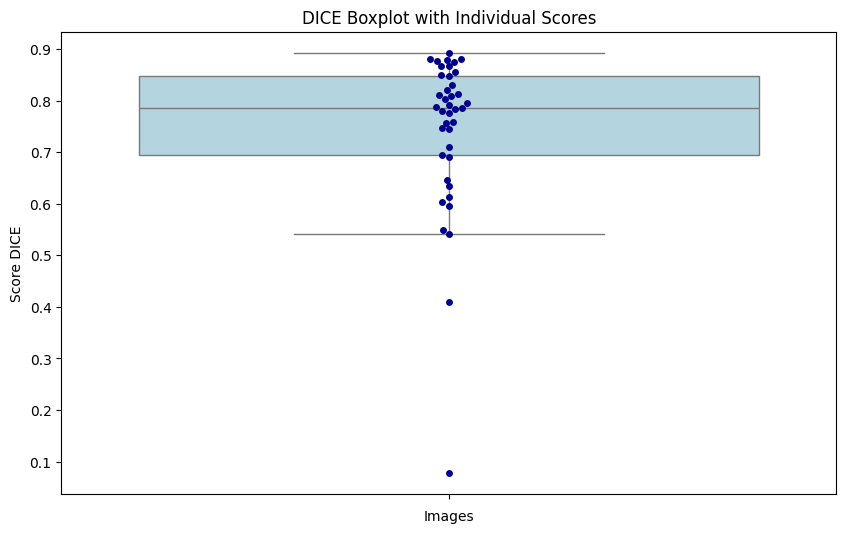

Median DICE score: 0.79, std: 0.15


In [7]:
# batch size used in validation
batch_size_val = 4

# patch size and overlap for gridSampler used in validation
patch_size_val = 128
patch_overlap_val = 64

# init
best_metric = -1
best_metric_epoch = -1
metric_values = []
    
# VALIDATION
dice_scores = []

model.eval()

# loop over all subject in validation set
for subject in tqdm(val_dataset):
    # define GridSampler for current subject
    grid_sampler = tio.inference.GridSampler(
        subject = subject,  
        patch_size = patch_size_val,
        patch_overlap = patch_overlap_val,
        padding_mode = 'constant'
    )
    patch_loader = torch.utils.data.DataLoader(grid_sampler, batch_size = batch_size_val)
    aggregator = tio.inference.GridAggregator(grid_sampler, overlap_mode = 'hann')
    
    # loop over patches to get model predictions
    for patches_batch in patch_loader:
        patch_inputs = torch.cat([patches_batch['flair'][tio.DATA], patches_batch['dwi'][tio.DATA], patches_batch['adc'][tio.DATA]], dim=1).to(DEVICE)
        patch_locations = patches_batch[tio.LOCATION]
        with torch.no_grad():
            patch_prediction = model(patch_inputs)
        patch_prediction_logits = torch.sigmoid(patch_prediction)
        aggregator.add_batch(patch_prediction_logits, patch_locations)

    # aggregate over patches
    aggregated_logits = aggregator.get_output_tensor()
    
    # compute validation dice and loss
    ground_truth_seg = subject['label'][tio.DATA]
    
    loss_val, dice, BCE = criterion_val(aggregated_logits, ground_truth_seg, is_validation=True)            
    dice_scores.append(dice.item())
    
    # Visualisation of the results by overlaying the FLAIR image with the groundtruth (in red) and the prediction mask (in blue) on the same image:
    flair = subject['flair'][tio.DATA].squeeze().numpy()
    ground_truth = ground_truth_seg.squeeze().numpy()
    prediction = aggregated_logits.squeeze().cpu().numpy()
    interactive_overlay(flair, ground_truth, prediction, dice.item())

boxplot(dice_scores)
print(f'Median DICE score: {np.median(dice_scores):.2f}, std: {np.std(dice_scores):.2f}')


## To boxplot the uncertainty rates and Correlate them with volumes


In [1]:
def boxplot2(list):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=list, color='lightblue', fliersize=0)  # Use a light color for the boxplot
    sns.swarmplot(data=list, color='darkblue')  # Plot individual scores in a darker color
    #plt.title("Uncertainty Boxplot with Individual Scores")
    plt.ylabel("Uncertainty rates") 
    plt.xlabel("Images")
    plt.show()

Volumes: [721.0, 16630.0, 1121.0, 91246.0, 30841.0, 10953.0, 75140.0, 1796.0, 25445.0, 22730.0, 940.0, 58775.0, 3468.0, 9646.0, 62823.0, 150348.0, 1019.0, 1075.0, 14254.0, 545.0, 122051.0, 1327.0, 5191.0, 44779.0, 858.0, 4449.0, 438.0, 8585.0, 123.0, 632.0, 168035.0, 778.0, 963.0, 14790.0, 610.0, 28680.0, 2857.0, 3540.0, 101067.0, 6458.0, 36458.0, 357.0, 21843.0, 218.0, 20667.0, 50464.0, 2214.0, 91289.0, 7727.0]
Ratios: [5.5e-09, 1.5e-09, 5.9e-09, 1e-09, 1.6e-09, 1e-09, 1.5e-09, 4.5e-09, 1.6e-09, 1.1e-09, 6.6e-09, 7e-10, 3.7e-09, 1.7e-09, 1.8e-09, 1.6e-09, 1.38e-08, 1.11e-08, 1.6e-09, 3.1e-09, 1.4e-09, 9e-09, 8.5e-09, 1.2e-09, 9.2e-09, 2.2e-09, 3.21e-08, 1.4e-09, 1.71e-08, 3.2e-09, 9e-10, 4.9e-09, 3.7e-09, 1.7e-09, 3.2e-09, 8e-10, 2.4e-09, 3.2e-09, 7e-10, 1.2e-09, 2.1e-09, 8.3e-09, 1.1e-09, 4.64e-08, 9e-10, 9e-10, 4.5e-09, 1.6e-09, 2e-09]


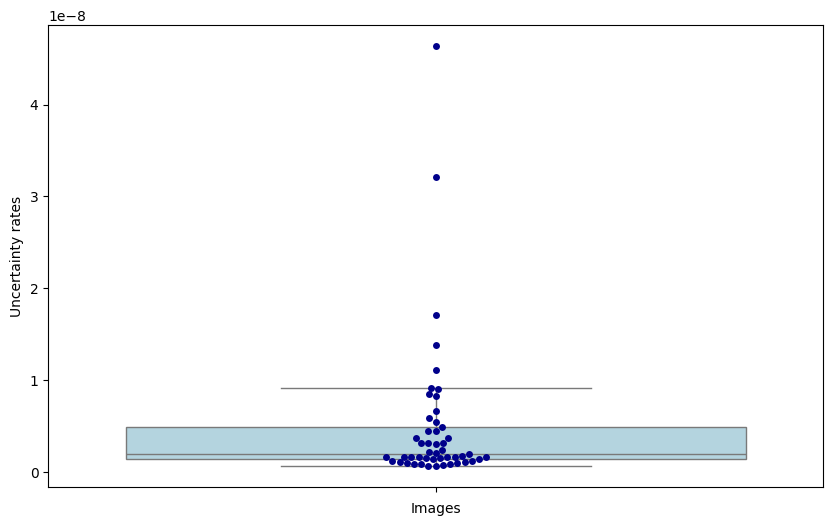

Median ratio: 0.000000002, std: 0.000000008, mean: 0.000000005


In [4]:
import os
import re

def extract_volume_and_ratio(directory):
    volume_list = []
    ratio_list = []
    
    # Define the regex pattern to extract sub number, volume, and ratio
    pattern = re.compile(r'sub-(\d+)_ses-.*_volume_(\d+\.\d+)_ratio_(\d+\.\d+)\.nii\.gz$')
    
    # Create a list to store tuples of (sub_number, volume, ratio)
    data = []
    
    # Iterate over all files in the directory
    for filename in os.listdir(directory):
        match = pattern.search(filename)
        if match:
            sub_number = int(match.group(1))
            volume = float(match.group(2))
            ratio = float(match.group(3))
            data.append((sub_number, volume, ratio))
    
    # Sort the data based on sub_number
    data.sort(key=lambda x: x[0])
    
    # Extract sorted volume and ratio lists
    for _, volume, ratio in data:
        volume_list.append(volume)
        ratio_list.append(ratio)
    
    return volume_list, ratio_list

# Example usage:
directory = '/home/user/Documents/raph/code/uncertainty_predictions'
volumes, ratios = extract_volume_and_ratio(directory)


volumes.pop(40)
ratios.pop(40)

print('Volumes:', volumes)
print('Ratios:', ratios)

boxplot2(ratios)

print(f'Median ratio: {np.median(ratios):.9f}, std: {np.std(ratios):.9f}, mean: {np.mean(ratios):.9f}')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


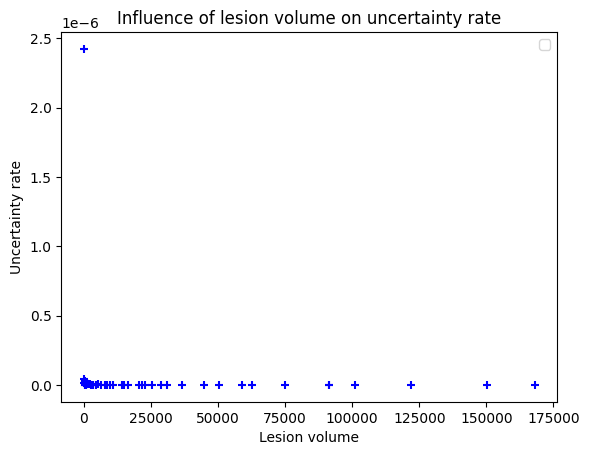

In [110]:
# Create the plot
plt.scatter(volumes, ratios, marker='+', color='b')

# Add labels and title
plt.xlabel('Lesion volume')
plt.ylabel('Uncertainty rate')
plt.title('Influence of lesion volume on uncertainty rate')

# Add a legend
plt.legend()

# Show the plot
plt.show()

## To boxplot the testing dices and Correlate them with ratios


In [87]:
import os
import re

def extract_sort_and_reduce_numbers(directory):
    numbers = []
    
    # Iterate through each file in the directory
    for filename in os.listdir(directory):
        # Use regex to find the pattern 'sub-(\d+)'
        match = re.search(r'sub-(\d+)', filename)
        
        if match:
            # Extract the number as an integer and add it to the list
            numbers.append(int(match.group(1)))
    
    # Sort the numbers from smallest to largest
    numbers.sort()
    
    # Remove every other number from the list (one index out of two)
    reduced_numbers = numbers[::2]
    
    return reduced_numbers

# Example usage:
directory_path = "/home/user/Documents/raph/code/uncertainty_predictions"
subject_numbers = extract_sort_and_reduce_numbers(directory_path)
print(subject_numbers)

[12, 17, 18, 19, 24, 25, 31, 34, 36, 39, 44, 47, 49, 50, 57, 62, 64, 68, 72, 79, 81, 82, 83, 86, 98, 108, 111, 114, 115, 119, 127, 128, 129, 146, 149, 155, 158, 159, 161, 163, 170, 173, 177, 180, 182, 192, 208, 216, 230, 250]


In [88]:
# Create the addresses
addresses = [f"sub-{num}_ses-0001_FLAIR.nii.gz_mean.nii.gz" for num in subject_numbers]
for i in range(len(addresses)):
    addresses[i] = os.path.join(directory_path,addresses[i])

print(addresses)


['/home/user/Documents/raph/code/uncertainty_predictions/sub-12_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-17_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-18_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-19_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-24_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-25_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-31_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-34_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-36_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/user/Documents/raph/code/uncertainty_predictions/sub-39_ses-0001_FLAIR.nii.gz_mean.nii.gz', '/home/us

In [89]:
directory_path2 = "/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives"
adresses2 = [f"sub-{num}/ses-0001/sub-{num}_ses-0001_msk.nii.gz" for num in subject_numbers]

for i in range(len(adresses2)):
    adresses2[i] = os.path.join(directory_path2,adresses2[i])

print(adresses2)

['/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-12/ses-0001/sub-12_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-17/ses-0001/sub-17_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-18/ses-0001/sub-18_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-19/ses-0001/sub-19_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-24/ses-0001/sub-24_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-25/ses-0001/sub-25_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-31/ses-0001/sub-31_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/sub-34/ses-0001/sub-34_ses-0001_msk.nii.gz', '/home/user/Documents/raph/preprocessed_datasets/ISLES2022/derivatives/

In [129]:
import nibabel as nib
import numpy as np

def compute_dice_coefficient(predictions, targets):
    # Convert to float using NumPy
    predictions = predictions.float()
    targets = targets.float()

    # Binarize the predictions (assuming the threshold is 0.5)
    predictions = (predictions > 0.5).to(torch.float)
    
    # Flatten the arrays
    predictions_flat = predictions.reshape(-1)
    targets_flat = targets.reshape(-1)
    
    # Compute intersection and union
    intersection = (predictions_flat * targets_flat).sum()
    sum_pred_target = predictions_flat.sum() + targets_flat.sum()
    
    # Compute Dice coefficient
    dice = (2. * intersection + 1e-6) / (sum_pred_target + 1e-6)

    return dice

def calculate_dices(list1, list2):
    dices = []
    
    # Ensure the lists are of the same length
    if len(list1) != len(list2):
        raise ValueError("The lists must have the same length")
    
    # Loop through the pairs of file paths
    for img_path1, img_path2 in zip(list1, list2):
        # Load the images
        img1 = nib.load(img_path1).get_fdata()
        img2 = nib.load(img_path2).get_fdata()
        
        img1_tensor = torch.from_numpy(img1)
        img2_tensor = torch.from_numpy(img2)

        # Compute the Dice coefficient
        dice = compute_dice_coefficient(img1_tensor, img2_tensor)
        
        # Append the result to the list
        dices.append(dice)
    
    return dices

dices = calculate_dices(addresses, adresses2)
print(dices)

[tensor(0.7066), tensor(0.8140), tensor(0.7273), tensor(0.8249), tensor(0.8052), tensor(0.7938), tensor(0.8327), tensor(0.6860), tensor(0.7649), tensor(0.8410), tensor(0.5980), tensor(0.9070), tensor(0.6018), tensor(0.7013), tensor(0.6867), tensor(0.7444), tensor(0.3905), tensor(0.2846), tensor(0.6354), tensor(0.6071), tensor(0.8529), tensor(0.7085), tensor(0.0856), tensor(0.9156), tensor(0.4242), tensor(0.7741), tensor(0.4700), tensor(0.8195), tensor(0.7325), tensor(0.8178), tensor(0.8795), tensor(0.6725), tensor(0.6855), tensor(0.7263), tensor(0.6259), tensor(0.8703), tensor(0.7151), tensor(0.7132), tensor(0.9151), tensor(0.8272), tensor(1.), tensor(0.8306), tensor(0.7002), tensor(0.8813), tensor(0.2353), tensor(0.8716), tensor(0.8451), tensor(0.6046), tensor(0.8052), tensor(0.7283)]


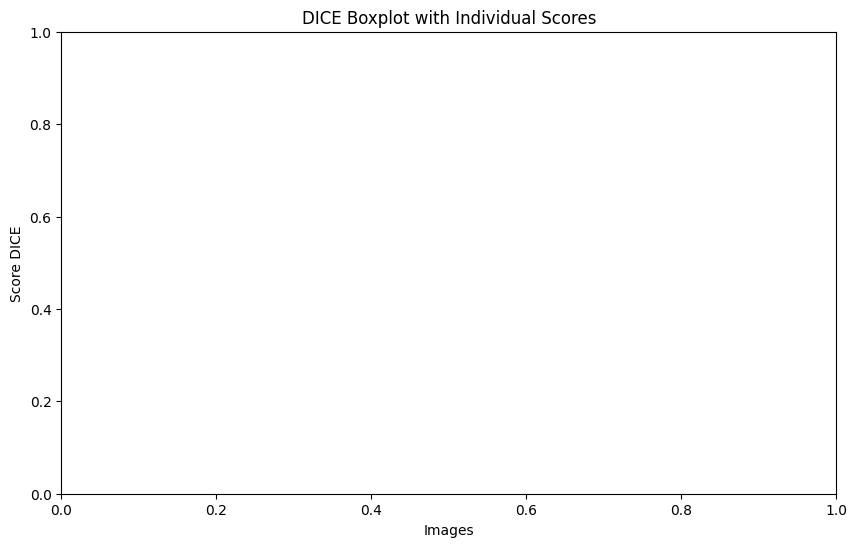

Median DICE score: 0.73, std: 0.18, mean: 0.71


In [130]:
boxplot(dices)
print(f'Median DICE score: {np.median(dices):.2f}, std: {np.std(dices):.2f}, mean: {np.mean(dices):.2f}')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


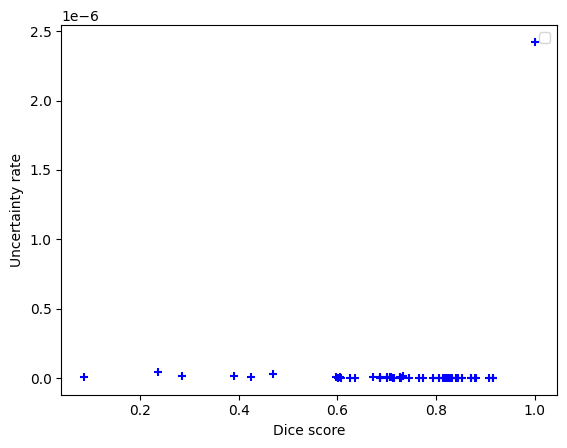

In [133]:
# Create the plot
plt.scatter(dices, ratios, marker='+', color='b')

# Add labels and title
plt.xlabel('Dice score')
plt.ylabel('Uncertainty rate')
#plt.title('Influence of Dice score on uncertainty rate')

# Add a legend
plt.legend()

# Show the plot
plt.show()

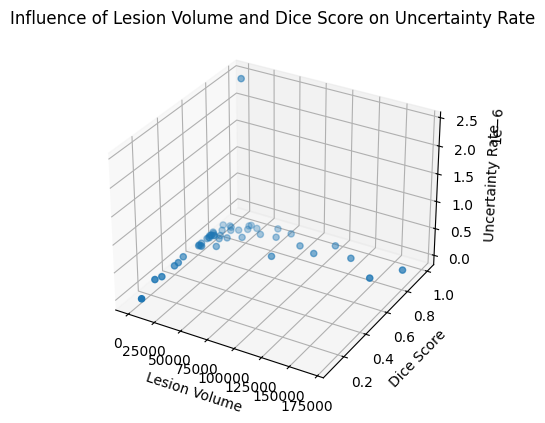

In [100]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a new figure for plotting
fig = plt.figure()

# Add a 3D subplot
ax = fig.add_subplot(111, projection='3d')

# Plot the data
ax.scatter(volumes, dices, ratios)

# Set labels for the axes
ax.set_xlabel('Lesion Volume')
ax.set_ylabel('Dice Score')
ax.set_zlabel('Uncertainty Rate')

# Set a title for the plot
ax.set_title('Influence of Lesion Volume and Dice Score on Uncertainty Rate')

# Show the plot
plt.show()